#### Tensor에 대한 사전 지식
    1. Tensor가 W를 통과해도 정보는 보존
    2. Weighted Sum의 가중치 합이 1(두 정보를 합치는데 두 정보를 각각 어느정도씩 합칠지를 Weight 비율에 맞게 합친다.)
    3. 내적: 정보가 얼마나 비슷한가(계산 값이 크면 정보가 비슷함, 계산 값이 작으면 정보가 다름)
------


#### attention 방식
- Decoder에서 Query(한 단어 예측할 때 Query 하나만 사용), Encoder에서 Key, Value를 만든다. 그 후 Query Tensor들과 Key Tensor들을 내적해서 얼마나 정보 간의 연관도가 있는지 확인하고 그 값을 Softmax에 input으로 넣어 가중치로 나타낸다.
구한 가중치를 각 Value에 곱한 뒤 모두 더하여 최종 Output을 만든다.

- **attention과 self-attention의 차이는 Q,K,V를 어디서 가져오는지의 차이 밖에 없다.**

#### 단어 Embedding

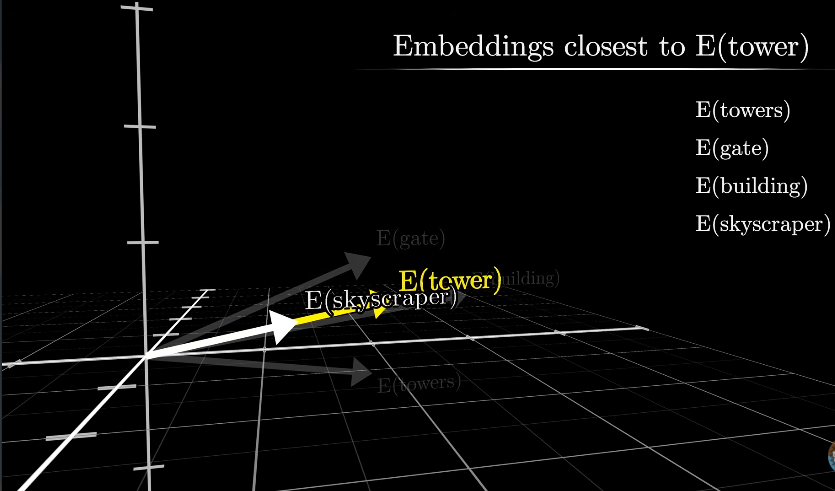

- 단어를 의미있는 매우 큰 차원의 백터로 나타낸다. 비슷한 백터일수록 비슷한 의미를 갖고있다.
#### Positional Encoding
- 그냥 attention만 하면 각 토큰의 순서가 바뀌어도 최종 값이 동일하기 때문에 순서를 알 수 없다. 그렇기 때문에 Positional Encoding을 더해서 위치 정보를 함께 전달한다.(Positional Encoding은 문장을 Embedding한 후에 바로 더해준다.)
 
 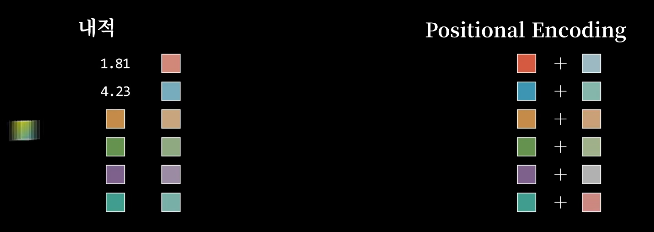

-----
 #### Self-Attention

 - 사용하는 이유: 위에서 Positional Encoding을 사용하여 문장의 위치 정보를 알았다고 해도 아직 문맥을 파악하지는 못하기 때문에 사용한다.

    1. 입력 문장을 임베딩하여 의미 있는 숫자 벡터로 변환한다.
    2. Positional Encoding을 더하여 단어의 위치 정보를 추가한다.
    3. Embedding에 각각 W_q, W_k, W_v를 곱해서 Query, Key, Value를 만든다.(이 점이 다르다.)


    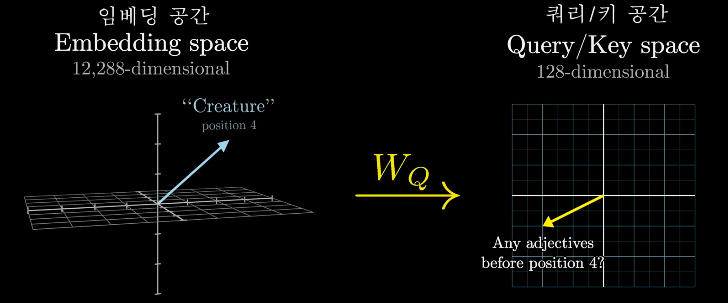



    4. 각 Query가 모든 Key와 내적하여 Attention Score를 계산한다.
    

    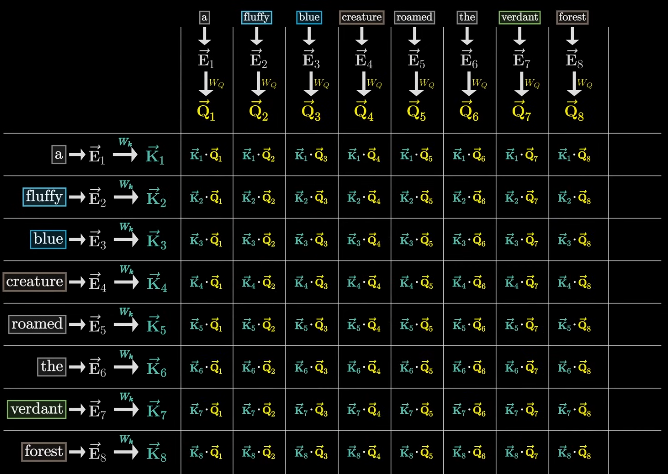


    5. Softmax를 이용해서 가중치를 만들고 그 후 Value 값을 곱하면 그 값이 Attention Output이 된다.

    6. Attention Output에 여러 층을 반복해서 나온 값이 Final Hidden Vector가 되고 (Final Hidden Vector * Unembedding Matrix)를 하여 Logits를 구하고 Softmax를 적용시켜 다음 단어를 예측할 확률을 구한다.



----


#### Masking
##### 사용 이유: 다음 단어를 예측하는 언어 모델에서는 현재 단어가 미래 단어를 미치 보면 안 된다. 그렇기 때문에 Masking을 써서 미래 단어들을 가려준다.

- 방식: 현재 시점보다 뒤에 있는 미래 단어들의 Score를 SoftMax 전에 매우 작은 음수로 바꾼다. -> Softmax를 적용하면 0이므로 미래 단어를 전혀 참고하지 못하게 된다.

-----

### Transformer: 번역하는 구조

- Encoder: 번역당하는(source) 문장
- Decoder: 번열할(target) 문장
- Decoder에 입력 문장을 다 쓰는 거는 예측해야 될 미래에 대해 이미 안 상태로 예상하는 거는 이미 예측이 아니라 이미 알고 있는 정답을 맞추는 것이기 때문에 말이 안 된다. 즉 Decoder self-attention에 Masking을 적용시킨다.
